### Imports

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from vizman import viz
import networkx as nx
from netneurotools.datasets import fetch_famous_gmat
from sklearn.model_selection import train_test_split
from echoes import ESNRegressor
from joblib import Parallel, delayed
from bct import randmio_und, latmio_und
from functools import partial


/Users/kf02/Library/Mobile Documents/com~apple~CloudDocs/Work/Presentations/OHBM 2026/.venv/lib/python3.11/site-packages/bct/algorithms/modularity.py:374: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if np.array(dc).shape is not ():


### Some helper functions

In [31]:
from typing import Callable, Tuple, List

def make_X_y(
    make_X: Callable,
    lags: np.ndarray,
    cut: int = 0,
) -> np.ndarray:
    """
    *** 
    Stolen from Fabrizio: 
    https://github.com/fabridamicelli/brain-connectivity-meets-reservoir-computing/blob/main/bioRNN/tasks/memory/capacity.py
    ***
    make_X: Callable
        Function to generate inputs. Should return a 1D np.ndarray.
        Note that the size of the output of make_X determines the size
        of X used for the task.
        Example:
        from functools import partial
        make_X = partial(np.random.uniform, low=-.5, high=.5, size=200)
    lags: np.ndarray
        Delays to be evaluated (memory capacity).
        For example: np.arange(1, 31, 5).
    cut: int, optional
        Number of initial steps to cut out.
        Make be at least larger than max(lags) if you want to avoid circle sequence.
    """
    X = make_X()
    if X.ndim == 1:
        X = X.reshape(-1, 1)
    y = _make_lagged_y(X, lags=lags)
    return X[cut:], y[cut:]

def _make_lagged_y(inputs: np.ndarray, lags: np.ndarray,) -> np.ndarray:
    """
    *** 
    Stolen from Fabrizio: 
    https://github.com/fabridamicelli/brain-connectivity-meets-reservoir-computing/blob/main/bioRNN/tasks/memory/capacity.py
    ***
    Generate delayed versions of inputs sequence.
    One sequence is generated for each lag value.

    Parameters
    ----------
    inputs: np.ndarray
        Signal to lag. It will be flattened before lagging,
        as it is supposed to be only one input chanel.
    lags: np.ndarray
        Delays to be evaluated (memory capacity).
        For example: np.arange(1, 31, 5).

    Returns
    -------
    lagged_inputs: np.ndarray of shape (len(inputs), len(lags))
        Array of lagged version of the inputs sequence.
        Each column represents U(t-k), where k is the lag.

    Examples
    --------
    >>> inputs = np.arange(5)
    >>> make_lagged_y(inputs, [1, 3])
    >>> array([[4., 2.],
               [0., 3.],
               [1., 4.],
               [2., 0.],
               [3., 1.]])

    >>> inputs = np.arange(5)
    >>> make_lagged_y(inputs, [1, 3])
    >>> array([[1., 4.],
               [2., 0.],
               [3., 1.]])
    """
    assert isinstance(inputs, np.ndarray), "inputs must be np.ndarray"
    inputs = inputs.flatten()
    inputs_lagged = np.zeros((len(inputs), len(lags)))
    for col, lag in enumerate(lags):
        inputs_lagged[:, col] = np.roll(inputs, lag)
    return inputs_lagged


def forgetting(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[List, float]:
    """
    *** 
    Stolen from Fabrizio: 
    https://github.com/fabridamicelli/brain-connectivity-meets-reservoir-computing/blob/main/bioRNN/tasks/memory/capacity.py
    ***
    Scoring function.
    Return forgetting curve (r2(k) for all k) and Memory capacity
    (sum over all values of the curve).

    y_pred and y_true are compared column-wise,
    assuming each column contains the values for a
    give delay.
    """
    assert y_pred.shape == y_true.shape, "y_pred and y_true must have same shape"
    assert y_pred.shape[0] > 1, "Error while computing forgetting: y_pred has less than 1 sample. Increase the number of samples (steps)"
    r2s = []
    for true, pred in zip(y_true.T, y_pred.T):
        r2 = np.corrcoef(true, pred)[0, 1]
        r2s.append(0 if r2 is None else r2 ** 2)
    return r2s, np.sum(r2s)


### Warming up & exploring the data a little bit

In [3]:
viz.set_visual_style()
viz_sizes = viz.load_data_from_json("sizes.json")
viz_colors = viz.load_data_from_json("colors.json")
viz_cmaps = viz.give_colormaps()
sns_kwargs = {"cmap": viz_cmaps["bw_lr"],
              "xticklabels":False,
              "yticklabels":False,
              "rasterized":True}

In [9]:
human_dataset = fetch_famous_gmat("human_struct_scale033")

Please cite the following papers if you are using this function:
  [primary]:
    
  [celegans]:
    Lav R Varshney, Beth L Chen, Eric Paniagua, David H Hall, and Dmitri B Chklovskii. Structural properties of the caenorhabditis elegans neuronal network. PLoS computational biology, 7(2):e1001066, 2011.
  [drosophila]:
    Ann-Shyn Chiang, Chih-Yung Lin, Chao-Chun Chuang, Hsiu-Ming Chang, Chang-Huain Hsieh, Chang-Wei Yeh, Chi-Tin Shih, Jian-Jheng Wu, Guo-Tzau Wang, Yung-Chang Chen, and others. Three-dimensional reconstruction of brain-wide wiring networks in drosophila at single-cell resolution. Current biology, 21(1):1–11, 2011.
  [human]:
    Alessandra Griffa, Yasser Alemán-Gómez, and Patric Hagmann. Structural and functional connectome from 70 young healthy adults [data set]. Zenodo, 2019.
  [macaque_markov]:
    Nikola T Markov, Maria Ercsey-Ravasz, Camille Lamy, Ana Rita Ribeiro Gomes, Loïc Magrou, Pierre Misery, Pascale Giroud, Pascal Barone, Colette Dehay, Zoltán Toroczkai, and o

In [12]:
connectome = human_dataset["conn"]

In [28]:
connectome.shape

(83, 83)

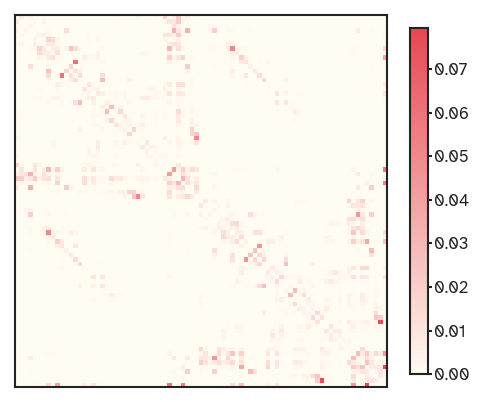

In [27]:
plt.figure(figsize=(4,4),dpi=150)
sns.heatmap(connectome, **sns_kwargs,square=True,cbar_kws={"shrink":0.75})
sns.despine(left=False,bottom=False,right=False,top=False)

### Testing memory capacity

In [205]:
lags = np.arange(1, 21)
X, y = make_X_y(
    make_X=partial(np.random.normal, loc=0, scale=0.5, size=5000),
    lags=lags,
    cut=0,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, shuffle=False, test_size=0.2
)


In [206]:
X.shape, y.shape

((5000, 1), (5000, 20))

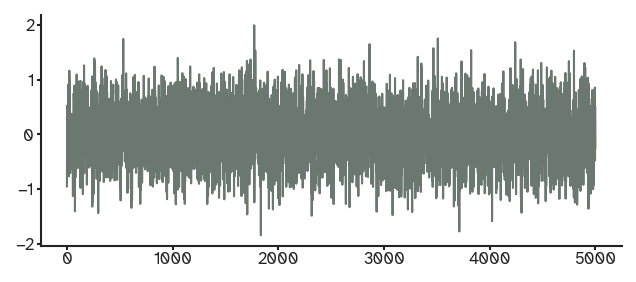

In [207]:
plt.figure(figsize=(5,2),dpi=150)
plt.plot(X)
sns.despine()

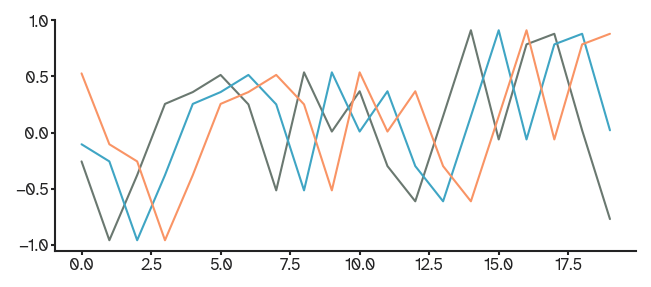

In [208]:
plt.figure(figsize=(5,2),dpi=150)
plt.plot(y[:20,0])
plt.plot(y[:20,1])
plt.plot(y[:20,2])

sns.despine()

In [209]:
esn = ESNRegressor(W=connectome,
                   n_transient=100)
y_pred = esn.fit(X_train, y_train).predict(X_test)


In [210]:
y_pred.shape

(1000, 20)

In [211]:
memory_curve, mc = forgetting(y_test, y_pred)

In [212]:
mc

np.float64(0.8876013384411775)

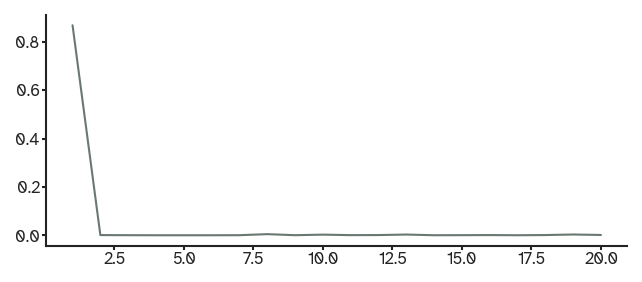

In [213]:
plt.figure(figsize=(5,2),dpi=150)
plt.plot(lags, memory_curve)
sns.despine()

### Quick hyperparameter search

In [230]:
spectral_radii = np.linspace(0.01, 3, 15)
input_scalings = np.linspace(0.01, 5, 15)
N_trials = 20
mcs = np.zeros((len(spectral_radii), len(input_scalings), N_trials))
for i, radius in tqdm(enumerate(spectral_radii), desc="Radiating & Scaling...", total=len(spectral_radii)):
    for j, scaling in enumerate(input_scalings):
        for trial in range(N_trials):
            esn = ESNRegressor(W=connectome,
                            spectral_radius=radius,
                            input_scaling=scaling,
                            n_transient=100,
                        random_state=trial)
            y_pred = esn.fit(X_train, y_train).predict(X_test)
            _, mc = forgetting(y_test, y_pred)
            mcs[i, j, trial] = mc


Radiating & Scaling...: 100%|██████████| 15/15 [01:52<00:00,  7.51s/it]


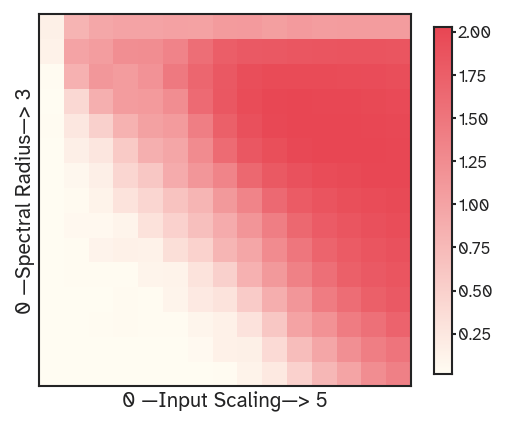

In [231]:
plt.figure(figsize=(4,4),dpi=150)
sns.heatmap(mcs.mean(2), **sns_kwargs,square=True,cbar_kws={"shrink":0.75})
plt.xlabel("0 —Input Scaling—> 5")
plt.ylabel("0 —Spectral Radius—> 3")
sns.despine(left=False,bottom=False,right=False,top=False)

In [232]:
best_radius_idx, best_scaling_idx = np.where(mcs.mean(2) == mcs.mean(2).max())
best_radius = spectral_radii[best_radius_idx[0]]
best_scaling = input_scalings[best_scaling_idx[0]]

print(f"Best spectral radius: {best_radius}")
print(f"Best input scaling: {best_scaling}")
print(f"Max memory capacity: {mcs.mean(2).max()}")

Best spectral radius: 0.8642857142857143
Best input scaling: 3.9307142857142856
Max memory capacity: 2.0269800444246533


### Looking into the model 

In [319]:
esn = ESNRegressor(W=connectome,
                   spectral_radius=best_radius,
                   input_scaling=best_scaling,
                   n_transient=100,
                   store_states_pred=True)
y_pred = esn.fit(X_train, y_train).predict(X_test)
memory_curve, mc = forgetting(y_test, y_pred)

In [321]:
mc

np.float64(2.093154328728103)

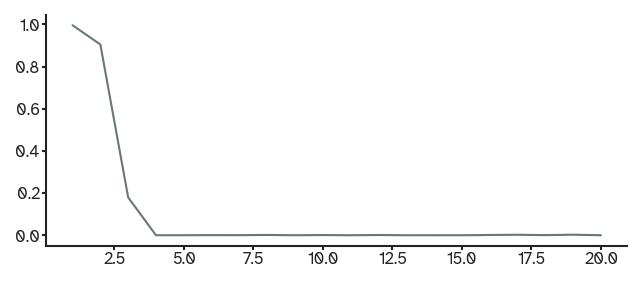

In [320]:
plt.figure(figsize=(5,2),dpi=150)
plt.plot(lags, memory_curve)
sns.despine()

In [291]:
esn.states_pred_.shape

(1000, 83)

In [292]:
X_test.shape

(1000, 1)

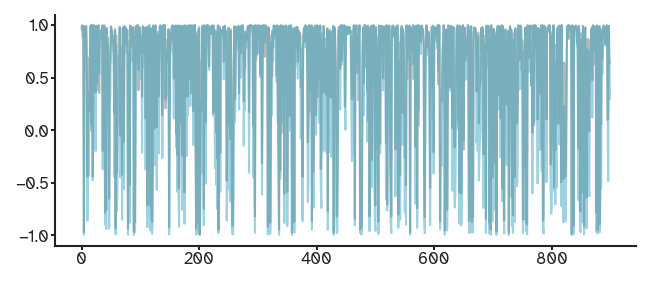

In [293]:
plt.figure(figsize=(5,2),dpi=150)
plt.plot(esn.states_pred_[100:,10],alpha=0.5)
plt.plot(esn.states_pred_[100:,5],alpha=0.5)

sns.despine()

In [294]:
strengths = connectome.sum(1)
variances = esn.states_pred_[100:].std(0)
means = esn.states_pred_[100:].mean(0)

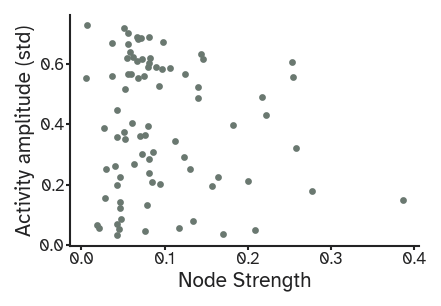

In [458]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(strengths, variances,s=5)
plt.xlabel("Node Strength")
plt.ylabel("Activity amplitude (std)")
sns.despine()

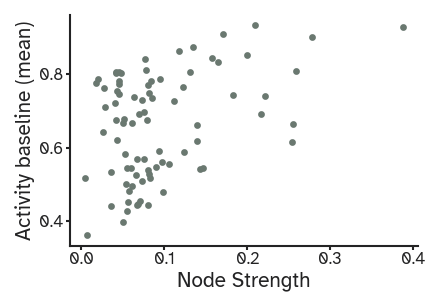

In [459]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(strengths, means,s=5)
plt.xlabel("Node Strength")
plt.ylabel("Activity baseline (mean)")
sns.despine()

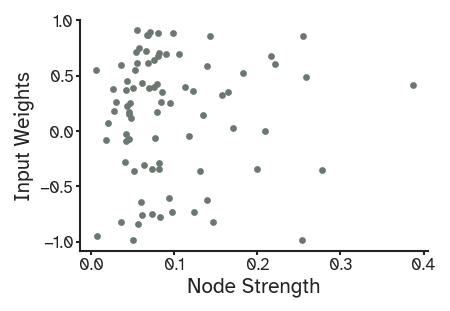

In [297]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(strengths, esn.W_in_,s=5)
plt.xlabel("Node Strength")
plt.ylabel("Input Weights")
sns.despine()

In [298]:
esn.W_out_.shape

(20, 84)

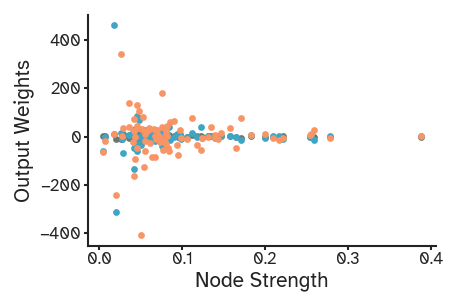

In [299]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(strengths, esn.W_out_[0,:-1],s=5)
plt.scatter(strengths, esn.W_out_[1,:-1],s=5)
plt.scatter(strengths, esn.W_out_[2,:-1],s=5)

plt.xlabel("Node Strength")
plt.ylabel("Output Weights")
sns.despine()

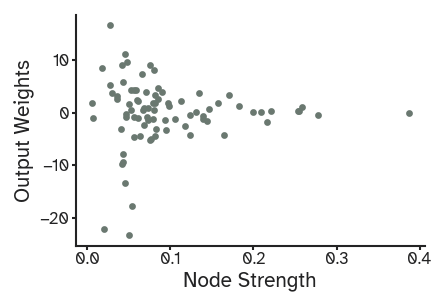

In [300]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(strengths, esn.W_out_[:,:-1].mean(0),s=5)
plt.xlabel("Node Strength")
plt.ylabel("Output Weights")
sns.despine()

### A bit of lesioning

In [301]:
from copy import deepcopy

In [347]:
lesioned_model = deepcopy(esn)
input_mask = np.ones_like(esn.W_in_)
top_n = 5
top_idx = np.argsort(strengths)[-top_n:]
input_mask[top_idx, ...] = 0.0

In [348]:
lesioned_model.W_in_ = lesioned_model.W_in_ * input_mask
y_pred = lesioned_model.fit(X_train, y_train).predict(X_test)

In [349]:
memory_curve, mc = forgetting(y_test, y_pred)
mc

np.float64(1.9177769292378026)

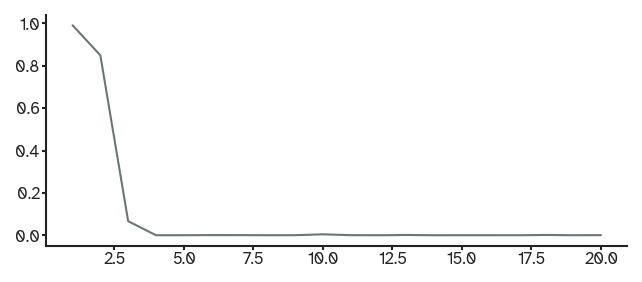

In [350]:
plt.figure(figsize=(5,2),dpi=150)
plt.plot(lags, memory_curve)
sns.despine()

In [368]:
N = 15
T = 100

ranked_idx = np.argsort(strengths)[::-1]
base_model = deepcopy(esn)
base_W_in = base_model.W_in_.copy()

mc_matrix = np.zeros((N, T))

for n in tqdm(range(1, N + 1), desc="Progressive lesioning"):
    lesion_idx = ranked_idx[:n]

    mask = np.ones_like(base_W_in)
    mask[lesion_idx, ...] = 0.0

    for t in range(T):
        model = deepcopy(base_model)
        model.W_in_ = base_W_in * mask
        model.random_state = t+n

        y_pred = model.fit(X_train, y_train).predict(X_test)
        _, mc_val = forgetting(y_test, y_pred)
        mc_matrix[n - 1, t] = mc_val


Progressive lesioning: 100%|██████████| 15/15 [00:37<00:00,  2.53s/it]


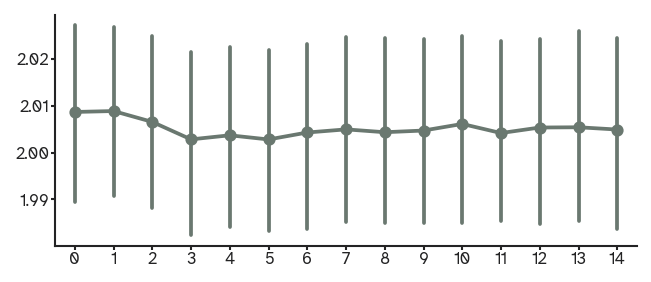

In [369]:
plt.figure(figsize=(5,2),dpi=150)
sns.pointplot(data=mc_matrix.T)
sns.despine()

### Same, but now we'll mess with the reservoir weights too

In [373]:
T = 100

ranked_idx = np.argsort(strengths)[::-1]
base_model = deepcopy(esn)
base_W_in = base_model.W_in_.copy()

mc_matrix = np.zeros((N, T))

for n in tqdm(range(1, N + 1), desc="Progressive lesioning"):
    lesion_idx = ranked_idx[:n]

    mask = np.ones_like(base_W_in)
    mask[lesion_idx, ...] = 0.0

    for t in range(T):
        model = deepcopy(base_model)
        model.W_in_ = base_W_in * mask
        model.W_ = model.W_ * mask
        model.random_state = t+n

        y_pred = model.fit(X_train, y_train).predict(X_test)
        _, mc_val = forgetting(y_test, y_pred)
        mc_matrix[n - 1, t] = mc_val


Progressive lesioning: 100%|██████████| 15/15 [00:38<00:00,  2.56s/it]


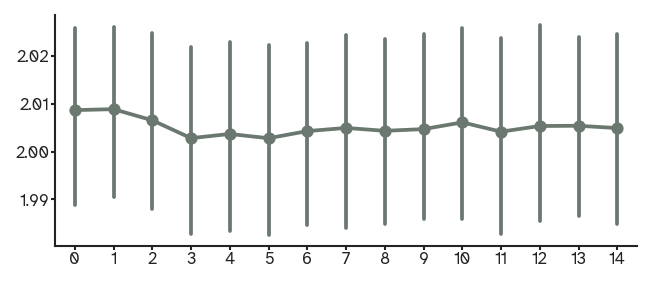

In [374]:
plt.figure(figsize=(5,2),dpi=150)
sns.pointplot(data=mc_matrix.T)
sns.despine()

### Time to lesion everything then

In [377]:
from msapy import msa

/Users/kf02/Library/Mobile Documents/com~apple~CloudDocs/Work/Presentations/OHBM 2026/.venv/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [ ]:
def lesion_and_evaluate(complements, network, X_train, y_train, X_test, y_test):
    mcs = []
    for lesion_combination in complements:
        lesioned_network = deepcopy(network)

        for trial in range(100):
            mask = np.ones(network.W_.shape[0])
            mask[lesion_combination] = 0.0
            lesioned_network.W_in_ = lesioned_network.W_in_ * mask
            lesioned_network.W_ = lesioned_network.W_ * mask
            lesioned_network.random_state = trial
            y_pred = lesioned_network.fit(X_train, y_train).predict(X_test)
            mcs.append(forgetting(y_test, y_pred)[1])
    performance = np.mean(mcs)
    return performance

In [402]:
lesion_esn_params = {'network': base_model, 
                     'X_train': X_train, 
                     'y_train': y_train, 
                     'X_test': X_test, 
                     'y_test': y_test}
regions = np.arange(connectome.shape[0])

In [ ]:
# contributions = msa.interface(multiprocessing_method='joblib',
#                                 elements=list(regions),
#                                 n_permutations=1000,
#                                 objective_function=lesion_and_evaluate,
#                                 objective_function_params=lesion_esn_params,
#                                 n_parallel_games=-1,
#                                 random_seed=1,
#                                 lazy=False)
# contributions.to_csv("contributions.csv")

/Users/kf02/Library/Mobile Documents/com~apple~CloudDocs/Work/Presentations/OHBM 2026/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/kf02/Library/Mobile Documents/com~apple~CloudDocs/Work/Presentations/OHBM 2026/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [429]:
import pandas as pd

In [ ]:
contributions = pd.read_csv("contributions.csv", index_col=0)

,0,1,2,3,4,5,6,7,8,9,...,73,74,75,76,77,78,79,80,81,82
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-8.881784e-16,0.0,4.440892e-16,0.000000e+00,0.000000e+00,8.881784e-16,...,4.440892e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.440892e-16,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000e+00,0.000000e+00,4.440892e-16,0.000000e+00,0.000000e+00,0.0,0.000000e+00,-4.440892e-16,-4.440892e-16,0.000000e+00,...,0.000000e+00,0.000000e+00,4.440892e-16,8.881784e-16,0.000000e+00,4.440892e-16,0.000000e+00,0.000000e+00,0.000000e+00,-4.440892e-16
2,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,-4.440892e-16,0.000000e+00,0.000000e+00,-8.881784e-16,...,4.440892e-16,0.000000e+00,0.000000e+00,4.440892e-16,0.000000e+00,0.000000e+00,0.000000e+00,4.440892e-16,0.000000e+00,-4.440892e-16
3,-4.440892e-16,4.440892e-16,-8.881784e-16,4.440892e-16,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,8.881784e-16,0.000000e+00,0.000000e+00,-8.881784e-16,0.000000e+00,0.000000e+00,4.440892e-16,0.000000e+00
4,4.440892e-16,4.440892e-16,-8.881784e-16,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,-4.440892e-16,...,0.000000e+00,0.000000e+00,0.000000e+00,4.440892e-16,0.000000e+00,0.000000e+00,4.440892e-16,0.000000e+00,4.440892e-16,4.440892e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.000000e+00,4.440892e-16,4.440892e-16,4.440892e-16,0.000000e+00,0.0,0.000000e+00,0.000000e+00,-4.440892e-16,0.000000e+00,...,0.000000e+00,4.440892e-16,-8.881784e-16,-4.440892e-16,0.000000e+00,4.440892e-16,0.000000e+00,0.000000e+00,-8.881784e-16,0.000000e+00
996,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,-8.881784e-16,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,-8.881784e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
997,8.881784e-16,4.440892e-16,4.440892e-16,0.000000e+00,0.000000e+00,0.0,0.000000e+00,-4.440892e-16,0.000000e+00,4.440892e-16,...,0.000000e+00,0.000000e+00,-8.881784e-16,0.000000e+00,4.440892e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.440892e-16
998,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,-4.440892e-16,0.000000e+00,0.000000e+00,...,-4.440892e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.440892e-16,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


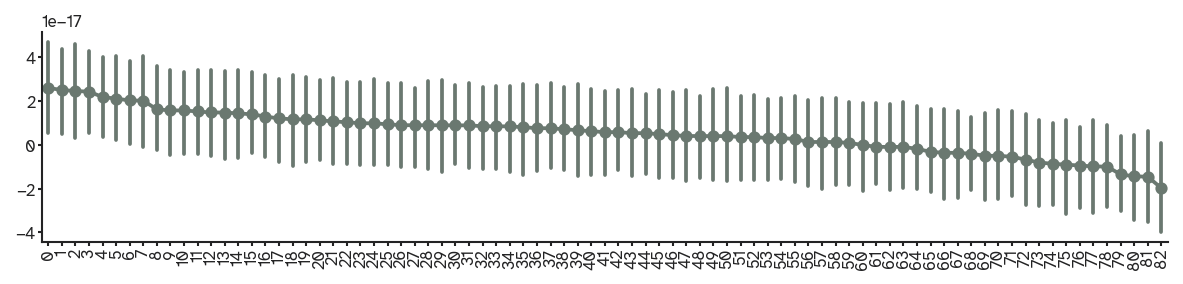

In [450]:
plt.figure(figsize=(8, 2), dpi=150)

avg_contrib = contributions.mean(axis=0).sort_values(ascending=False)
sorted_cols = avg_contrib.index

sorted_data = contributions.loc[:, sorted_cols].copy()

sorted_data.columns = range(len(sorted_cols))

sns.pointplot(data=sorted_data)
sns.despine()
plt.xticks(rotation=90)
plt.tight_layout()


In [ ]:
sorted_data_z = (sorted_data - sorted_data.mean()) / sorted_data.std()

# optional quick check
sorted_data_z.head()

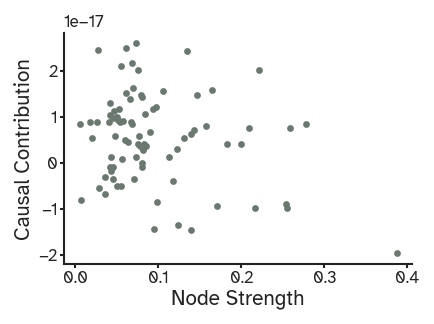

In [428]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(strengths, avg_contrib,s=5)
plt.xlabel("Node Strength")
plt.ylabel("Causal Contribution")
sns.despine()

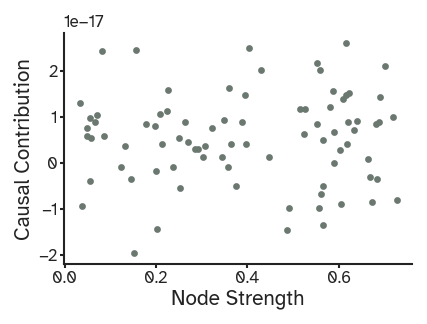

In [439]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(variances, avg_contrib,s=5)
plt.xlabel("Node Strength")
plt.ylabel("Causal Contribution")
sns.despine()

### Try more network measures

In [440]:
import netneurotools.metrics as nntm

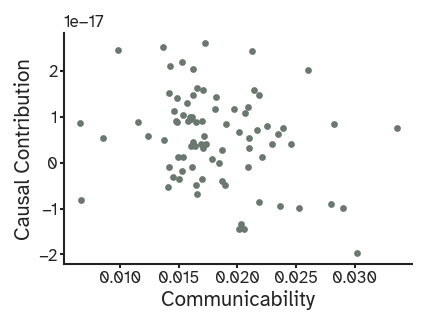

In [442]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(nntm.communicability_wei(connectome).mean(0), avg_contrib,s=5)
plt.xlabel("Communicability")
plt.ylabel("Causal Contribution")
sns.despine()

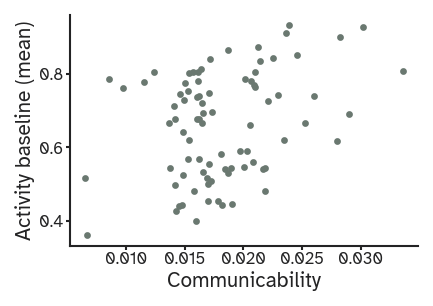

In [457]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(nntm.communicability_wei(connectome).mean(0), means,s=5)
plt.xlabel("Communicability")
plt.ylabel("Activity baseline (mean)")
sns.despine()

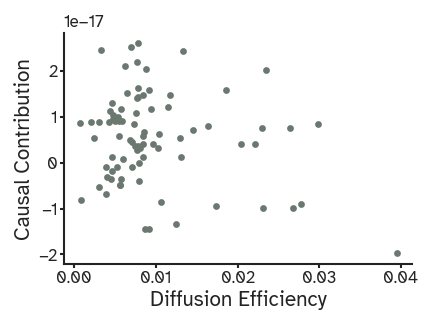

In [453]:
plt.figure(figsize=(3,2),dpi=150)
plt.scatter(nntm.diffusion_efficiency(connectome)[1].mean(0), avg_contrib,s=5)
plt.xlabel("Diffusion Efficiency")
plt.ylabel("Causal Contribution")
sns.despine()